# Preisvorhersage mit einem Regressionsbaum

## 1. Einleitung

Dieses Notebook baut auf der bereinigten Datengrundlage aus der explorativen
Analyse auf. Ziel ist es, den Angebotspreis eines Gebrauchtwagens mithilfe eines
Regressionsbaums vorherzusagen und damit die zweite Forschungsfrage zu beantworten,
wie gut sich der Preis anhand der Fahrzeugmerkmale schätzen lässt.

Der Regressionsbaum wurde gewählt, weil er auch nichtlineare Zusammenhänge und
Wechselwirkungen zwischen Merkmalen abbilden kann und seine Entscheidungen gut
nachvollziehbar bleiben. Als Vergleichsmaßstab dient ein einfaches Baseline-Modell,
damit sich der Mehrwert des Regressionsbaums beurteilen lässt. Die Güte des Modells
wird mit den Kennzahlen R², RMSE und MAE bewertet und zusätzlich durch eine
Kreuzvalidierung abgesichert.

## 2. Setup

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.dummy import DummyRegressor

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold

# Darstellung
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Pfade, eigener Bilder-Ordner für dieses Notebook
DATA_PROCESSED = Path("../data/processed/data_processed.csv")
IMG_DIR = Path("../images/modeling/regressionsbaum")
IMG_DIR.mkdir(parents=True, exist_ok=True)

# Gemeinsame Bewertungsfunktionen aus src/metrics.py
import sys
sys.path.append("../src")
from metrics import kennzahlen, speichere_ergebnis


In [2]:
# Bereinigte Daten laden
df = pd.read_csv(DATA_PROCESSED)
print("Shape:", df.shape)
df.head()

Shape: (243060, 10)


,brand,model,color,registration_month,year,mileage_in_km,power_ps,transmission_type,fuel_type,price_in_euro
0,alfa-romeo,Alfa Romeo GTV,red,10,1995,160500.0,201,Manual,Petrol,1300.0
1,alfa-romeo,Alfa Romeo 164,black,2,1995,190000.0,260,Manual,Petrol,24900.0
2,alfa-romeo,Alfa Romeo Spider,black,7,1995,189500.0,150,Manual,Petrol,4900.0
3,alfa-romeo,Alfa Romeo 164,red,11,1996,96127.0,179,Manual,Petrol,17950.0
4,alfa-romeo,Alfa Romeo Spider,red,4,1996,47307.0,150,Manual,Petrol,7900.0


## 3. Merkmalsauswahl und Vorbereitung

In [3]:
# Anzahl Ausprägungen und Datentyp je Spalte
for spalte in df.columns:
    print(f"{spalte:22s} {df[spalte].nunique():>7d}   {df[spalte].dtype}")

brand                       47   object
model                     1306   object
color                       14   object
registration_month          12   int64
year                        29   int64
mileage_in_km            71517   float64
power_ps                   495   int64
transmission_type            3   object
fuel_type                   10   object
price_in_euro            18025   float64


Die Spalte `model` wird entfernt, weil sie zu viele Modellvarianten je Hersteller enthält. Diese Herstellerinformation ist bereits in der Spalte `brand` abgedeckt. Auch `registration_month` wird entfernt, weil der Zulassungsmonat keinen erkennbaren Einfluss auf den Preis hat.

In [4]:
# Zielgröße festlegen
ziel = "price_in_euro"

# Merkmale nach Typ trennen
num_features = ["year", "mileage_in_km", "power_ps"]
kat_features = ["brand", "color", "transmission_type", "fuel_type"]

# Merkmalsmatrix und Zielgröße bilden
X = df[num_features + kat_features]
y = df[ziel]

# Kontrolle der Form
print("Merkmale X:", X.shape)
print("Zielgröße y:", y.shape)

Merkmale X: (243060, 7)
Zielgröße y: (243060,)


In [5]:
# Kontrolle auf fehlende Werte in den ausgewählten Merkmalen
X.isna().sum()

year                 0
mileage_in_km        0
power_ps             0
brand                0
color                0
transmission_type    0
fuel_type            0
dtype: int64

Die Merkmalsmatrix X umfasst 243060 Zeilen und sieben Spalten, was den drei numerischen und den vier kategorialen Merkmalen entspricht. Die Zielgröße y enthält passend dazu 243060 Werte. In keinem der sieben Merkmale treten fehlende Werte auf, sodass der Datensatz vollständig ist und keine Imputation nötig ist.

## 4. Train-Test-Split und Encoding

In [6]:
# Zuerst aufteilen, bevor irgendetwas aus den Daten gelernt wird
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20 Prozent der Daten dienen als Test
    random_state=42     # feste Zufallszahl macht die Aufteilung reproduzierbar
)

print("Training:", X_train.shape, "Test:", X_test.shape)

Training: (194448, 7) Test: (48612, 7)


In [7]:
# Vorverarbeitung, die nur die kategorialen Merkmale kodiert
preprocessor = ColumnTransformer(
    transformers=[
        ("kat", OneHotEncoder(handle_unknown="ignore"), kat_features),
    ],
    remainder="passthrough"   # die numerischen Merkmale bleiben unverändert
)

# Zur Veranschaulichung nur auf den Trainingsdaten anpassen
preprocessor.fit(X_train)
print("Anzahl Merkmale nach Kodierung:", preprocessor.get_feature_names_out().shape[0])

Anzahl Merkmale nach Kodierung: 77


Durch die Kodierung entstehen aus den vier kategorialen Merkmalen 74 einzelne Ja/Nein-Spalten, die zusammen mit den drei unveränderten numerischen Merkmalen 77 Merkmale ergeben. Da der Vorverarbeiter ausschließlich auf den Trainingsdaten angepasst wurde, bleiben die Testdaten wirklich unbekannt und Data Leakage wird vermieden.

## 5. Baseline

In [8]:
# Baseline, die unabhängig von den Merkmalen immer den mittleren Trainingspreis vorhersagt
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train[num_features], y_train)

print("Mittlerer Trainingspreis:", round(y_train.mean(), 2), "Euro")

Mittlerer Trainingspreis: 26142.0 Euro


## 6. Regressionsbaum

In [9]:
# Pipeline aus Vorverarbeitung und Regressionsbaum
baum = Pipeline(steps=[
    ("vorverarbeitung", preprocessor),
    ("modell", DecisionTreeRegressor(max_depth=10, random_state=42))
])

# Training ausschließlich auf den Trainingsdaten
baum.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vorverarbeitung', ...), ('modell', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('kat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

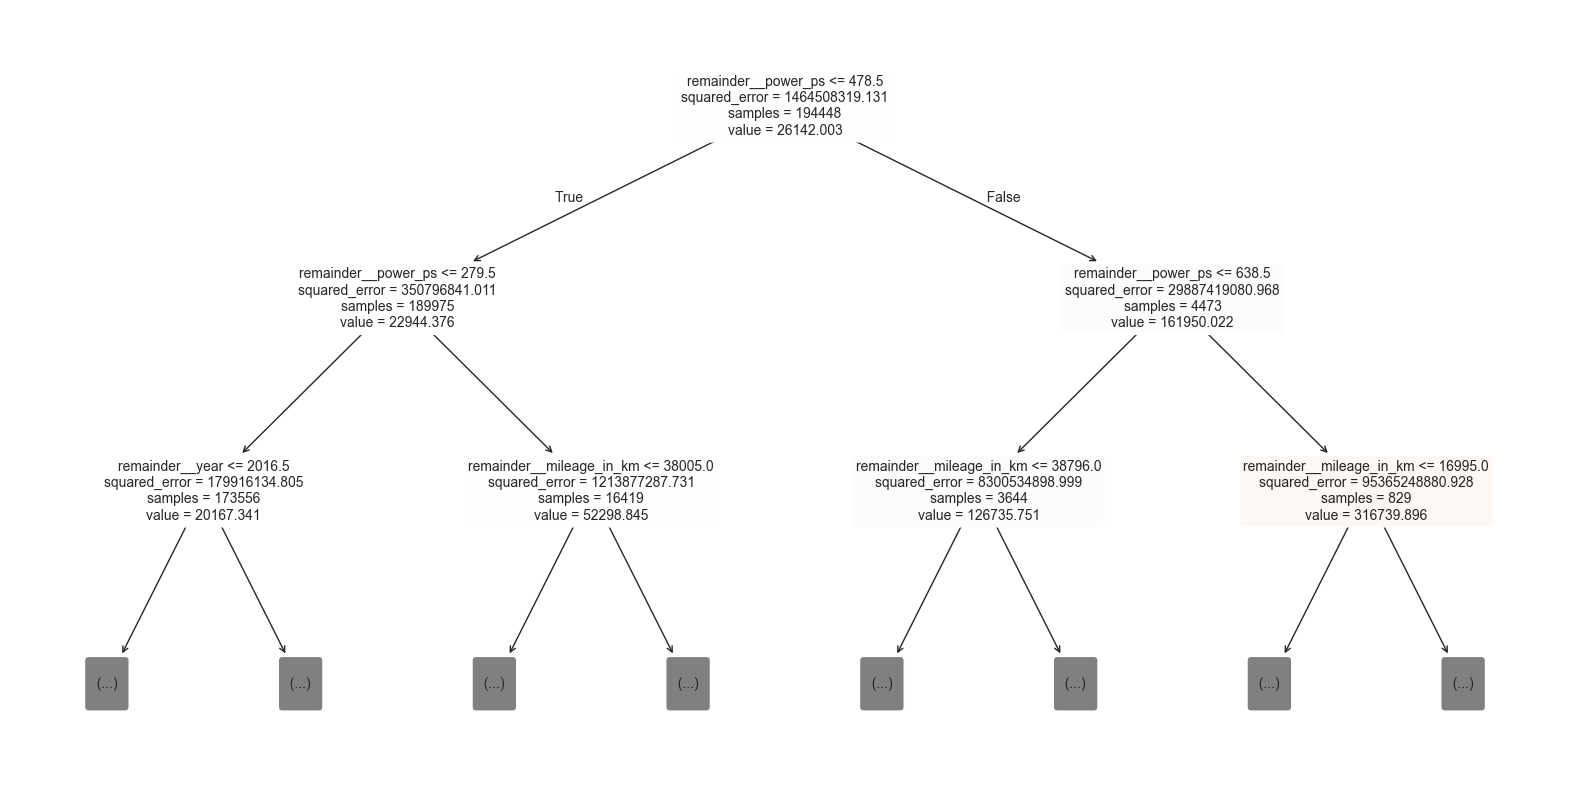

In [10]:
# Merkmalsnamen nach der Kodierung holen
feature_names = baum.named_steps["vorverarbeitung"].get_feature_names_out()

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    baum.named_steps["modell"],
    max_depth=2,                 # nur die obersten Ebenen zur Lesbarkeit
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
plt.savefig(IMG_DIR / "baum_struktur.png", dpi=150, bbox_inches="tight")
plt.show()

Der Baum trifft seine erste Aufteilung anhand der Motorleistung und trennt damit einen kleinen, aber sehr teuren Hochleistungsbereich vom breiten Marktsegment ab. In den weiteren Ebenen nutzt er vor allem Leistung, Baujahr und Laufleistung, was die numerischen Preistreiber aus der explorativen Analyse bestätigt. Der Zweig mit sehr hoher Leistung und geringer Laufleistung isoliert die hochpreisigen Sportwagen mit einem durchschnittlichen Preis von über 300000 Euro.

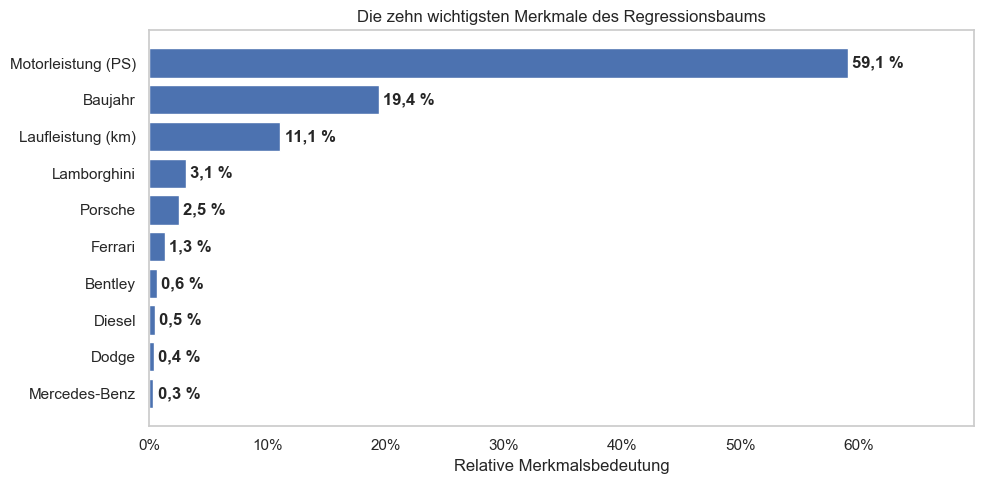

In [11]:

NAMEN = {
    "power_ps":      "Motorleistung (PS)",
    "year":          "Baujahr",
    "mileage_in_km": "Laufleistung (km)",
}

def deutscher_name(name):
    if name in NAMEN:
        return NAMEN[name]
    for spalte in kat_features:
        if name.startswith(spalte + "_"):
            return name[len(spalte) + 1:].title()
    return name

# Wichtigkeit der Merkmale aus dem trainierten Baum
importances = pd.Series(
    baum.named_steps["modell"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)
importances.index = importances.index.str.replace("remainder__", "").str.replace("kat__", "")

# Die zehn wichtigsten Merkmale
top10 = importances.head(10).sort_values()
top10.index = [deutscher_name(n) for n in top10.index]

fig, ax = plt.subplots(figsize=(10, 5))
balken = ax.barh(top10.index, top10.values, color="#4C72B0")

ax.bar_label(
    balken,
    labels=[f"{w*100:.1f} %".replace(".", ",") for w in top10.values],
    padding=3,
    fontweight="bold"
)

ax.set_xlim(0, top10.values.max() * 1.18)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("Relative Merkmalsbedeutung")
ax.set_title("Die zehn wichtigsten Merkmale des Regressionsbaums")
ax.grid(False)

plt.tight_layout()
plt.savefig(IMG_DIR / "merkmalswichtigkeit.png", dpi=150, bbox_inches="tight")
plt.show()

Die `Motorleistung (PS)`, das `Baujahr` und die `Laufleistung (km)` erklären zusammen rund 89 Prozent der Vorhersagekraft des Modells. Von den kategorialen Merkmalen tragen nur einzelne Premiummarken wie Lamborghini und Porsche spürbar bei, indem sie das Hochpreissegment feiner abbilden. Da die Merkmalsbedeutung eines einzelnen Baums numerische Merkmale bevorzugt, werden die Werte als Rangordnung interpretiert.

## 7. Bewertung und Robustheit

In [12]:
# Vorhersagen auf den Testdaten
y_pred_baseline = baseline.predict(X_test[num_features])
y_pred_baum = baum.predict(X_test)

# Kennzahlen aus src/metrics.py, identisch für beide Modell-Notebooks
r2_b, rmse_b, mae_b = kennzahlen(y_test, y_pred_baseline)
r2_t, rmse_t, mae_t = kennzahlen(y_test, y_pred_baum)

# Ergebnisse gegenüberstellen
ergebnisse = pd.DataFrame({
    "Baseline": [r2_b, rmse_b, mae_b],
    "Regressionsbaum": [r2_t, rmse_t, mae_t],
}, index=["R²", "RMSE (Euro)", "MAE (Euro)"])

ergebnisse.round(2)


,Baseline,Regressionsbaum
R²,-0.00,0.79
RMSE (Euro),32112.64,14564.66
MAE (Euro),15528.79,5153.73


Der Regressionsbaum erklärt mit einem R² von 0,79 rund 79 Prozent der Preisschwankung auf den Testdaten und übertrifft die Baseline in allen drei Kennzahlen deutlich. Im Durchschnitt weicht seine Schätzung um etwa 5150 Euro vom tatsächlichen Preis ab. Dass der RMSE mit 14565 Euro spürbar über dem MAE liegt, zeigt, dass einzelne sehr teure Fahrzeuge zu großen Einzelfehlern führen, während der Fehler bei typischen Fahrzeugen geringer ausfällt.

In [13]:
# Kreuzvalidierung zur Absicherung, fünf Durchläufe auf den Trainingsdaten
cv_scores = cross_val_score(baum, X_train, y_train, cv=5, scoring="r2")

print("R² je Durchlauf:", cv_scores.round(3))
print("Mittelwert:", cv_scores.mean().round(3))
print("Streuung (Std):", cv_scores.std().round(3))

R² je Durchlauf: [0.649 0.249 0.059 0.475 0.584]
Mittelwert: 0.403
Streuung (Std): 0.219


In [14]:
# Robustheit anhand des MAE, der unempfindlicher gegenüber Extremwerten ist
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_cv = -cross_val_score(baum, X_train, y_train, cv=kf, scoring="neg_mean_absolute_error")

print("MAE je Durchlauf (Euro):", mae_cv.round(0))
print("Mittelwert (Euro):", round(mae_cv.mean()))
print("Streuung (Euro):", round(mae_cv.std()))

MAE je Durchlauf (Euro): [5370. 5462. 5270. 5230. 5575.]
Mittelwert (Euro): 5381
Streuung (Euro): 126


Die Kennzahlen werden in `results/` abgelegt, damit die Vergleichstabelle am Ende
von Notebook 03 ohne manuelle Übertragung von Zahlen entstehen kann.

In [15]:
# Ergebnisse für den Modellvergleich ablegen
speichere_ergebnis("Baseline", rang=1, r2_test=r2_b, rmse_test=rmse_b, mae_test=mae_b)
speichere_ergebnis("Regressionsbaum", rang=2, r2_test=r2_t, rmse_test=rmse_t, mae_test=mae_t,
                   r2_cv=cv_scores, mae_cv=mae_cv)
print("Ergebnisse in results/ gespeichert.")


Ergebnisse in results/ gespeichert.


Die Kreuzvalidierung des R² schwankt stark zwischen 0,06 und 0,65, weil das R² auf quadrierten Fehlern beruht und dadurch von den wenigen extrem teuren Fahrzeugen dominiert wird. Der einzelne Testwert von 0,79 ist daher als optimistisch einzuordnen. Der über dieselbe Kreuzvalidierung bestimmte MAE ist mit rund 5381 Euro und einer Streuung von nur 126 Euro dagegen sehr stabil. Das Modell schätzt den Preis typischer Fahrzeuge somit zuverlässig, während es bei den seltenen Luxusfahrzeugen naturgemäß unsicher bleibt.

## 8. Zwischenfazit 

In diesem Notebook wurde geprüft, wie gut sich der Angebotspreis mit einem Regressionsbaum vorhersagen lässt. Als Merkmale dienten `power_ps`, `year`, `mileage_in_km`, `brand`, `color`, `transmission_type` und `fuel_type`, während `model` und `registration_month` mit Begründung entfernt wurden. Die Kodierung erfolgte erst nach dem Train-Test-Split, um Data Leakage zu vermeiden. Der Baum stützt sich vor allem auf die Motorleistung, das Baujahr und die Laufleistung, die zusammen rund 89 Prozent der Vorhersagekraft erklären.

Gegenüber der Baseline zeigt der Baum einen klaren Mehrwert und senkt den mittleren absoluten Fehler auf etwa 5150 Euro. Die Kreuzvalidierung bestätigt diese Genauigkeit für typische Fahrzeuge mit einem sehr stabilen Fehler von rund 5381 Euro. Das Bestimmtheitsmaß schwankt dagegen stark, weil es auf quadrierten Fehlern beruht und von den wenigen extrem teuren Fahrzeugen dominiert wird, weshalb der Testwert von 0,79 als optimistisch gilt. Das Modell schätzt normale Fahrzeuge somit zuverlässig, bleibt bei Luxusfahrzeugen aber unsicher. Das folgende Notebook stellt mit der multiplen Regression ein zweites Modell zum Vergleich bereit.